In [61]:
import pandas as pd

df = pd.read_csv('Cleaned_Superstore.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month-Year,Year_Month,Shipping Time
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Nov-2016,2016-11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Nov-2016,2016-11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Jun-2016,2016-06,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Oct-2015,2015-10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Oct-2015,2015-10,7


In [62]:
df.drop(columns=['Row ID', 'Postal Code']).describe().round(2)

,Sales,Quantity,Discount,Profit,Shipping Time
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,3.96
std,623.25,2.23,0.21,234.26,1.75
min,0.44,1.00,0.00,-6599.98,0.00
25%,17.28,2.00,0.00,1.73,3.00
50%,54.49,3.00,0.20,8.67,4.00
75%,209.94,5.00,0.20,29.36,5.00
max,22638.48,14.00,0.80,8399.98,7.00


In [63]:
# Shape of the dataset
df.shape

(9994, 24)

In [64]:
# Columns names and their info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [65]:
# Check for missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month-Year       0
Year_Month       0
Shipping Time    0
dtype: int64

In [66]:
# Strip white spaces from column names
df.columns.str.strip()

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Month-Year',
       'Year_Month', 'Shipping Time'],
      dtype='str')

In [67]:
# the number of unique values in each column (including NaN as unique value)
df.nunique(dropna=False)

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
Month-Year         48
Year_Month         48
Shipping Time       8
dtype: int64

In [68]:
# Identify & Drop duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Visualization

### → Sum of Categories

In [69]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

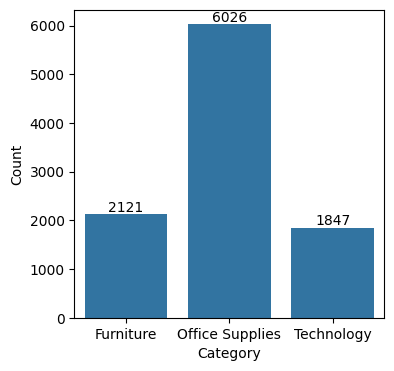

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (4, 4))
ax = sns.countplot(data=df, x = 'Category')
ax.bar_label(ax.containers[0])
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

-------

### → Monthly Trend

In [76]:
# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)

df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)


In [77]:
df['Month-Year'] = df['Order Date'].dt.strftime('%b-%Y') # Readable format
df['Year_Month'] = df['Order Date'].dt.to_period('M') # datetime period format
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month-Year,Year_Month,Shipping Time
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,Aug-2016,2016-08,92


In [80]:
# Monthly Sales Trend
monthly_sales = df.groupby('Year_Month')['Sales'].sum().round(2)

monthly_sales.head(10)

Year_Month
2014-01    28953.71
2014-02    12743.11
2014-03    54801.91
2014-04    24710.02
2014-05    29639.83
2014-06    29287.03
2014-07    35341.25
2014-08    37854.55
2014-09    66110.22
2014-10    34561.95
Freq: M, Name: Sales, dtype: float64

In [81]:
print(type(monthly_sales))

<class 'pandas.Series'>


In [83]:
# Highest sales point

max_idx = monthly_sales.idxmax()
max_value = monthly_sales.max()

print(max_idx)
print(max_value)

2017-11
89306.24


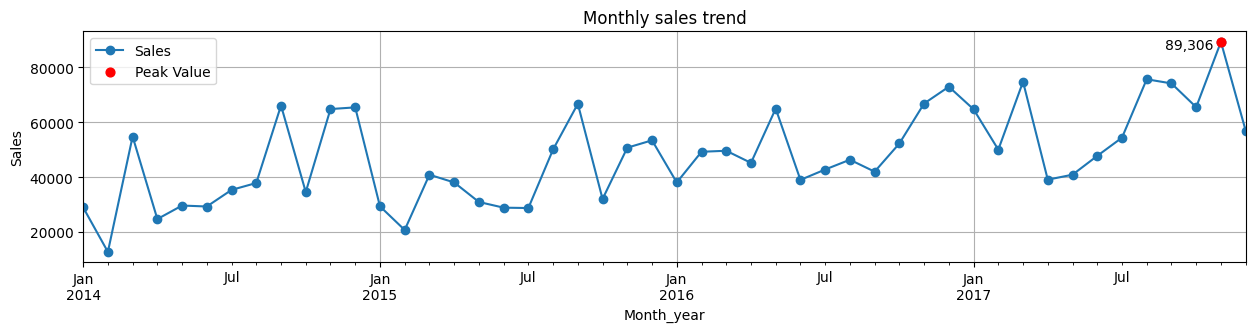

In [84]:
plt.figure(figsize=(15,3))
monthly_sales.plot(kind='line', marker='o', title='Monthly sales trend')
plt.xlabel('Month_year')
plt.ylabel('Sales')
plt.grid()

# Highlighting peak
plt.scatter(max_idx, max_value, color='red', s=40, zorder = 5, label = 'Peak Value')

plt.annotate(
    f'{max_value:,.0f}',
    (max_idx, max_value),
    xytext=(-5,-5),
    textcoords='offset points',
    ha='right')

plt.legend()
plt.show()

# Time-series forecasting

00:33:24 - cmdstanpy - INFO - Chain [1] start processing
00:33:24 - cmdstanpy - INFO - Chain [1] done processing


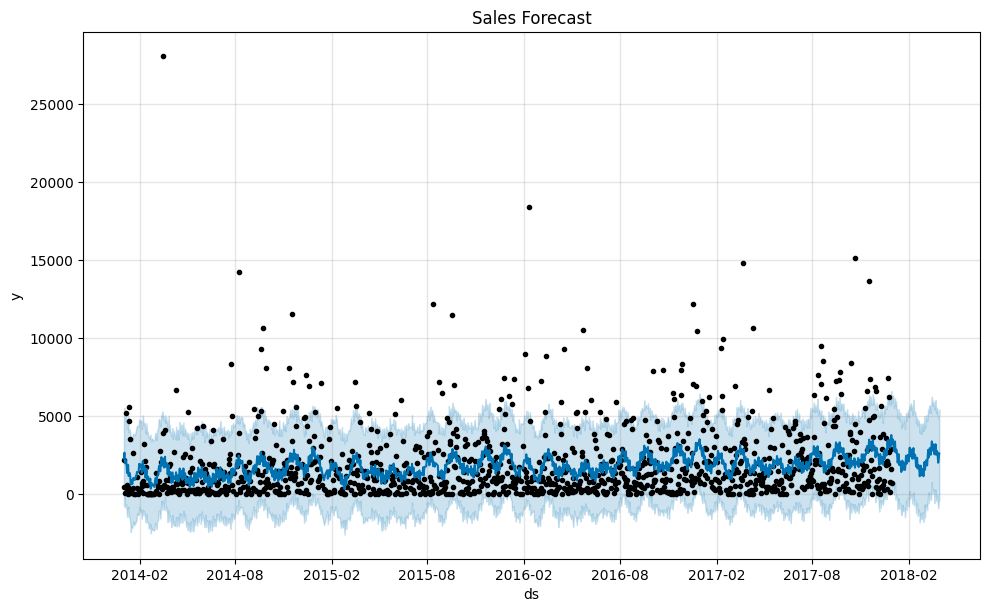

In [88]:
from prophet import Prophet

# Preparing data
sales_df = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_df = sales_df.rename(columns={
    "Order Date" : "ds",
    "Sales" : "y"
})

# Training Model
model = Prophet()
model.fit(sales_df)

# Future Dataframe
future = model.make_future_dataframe(periods=90) # Next 90 days
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

## Most Demanded Sub-categories 

In [125]:
top_products = df.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False)

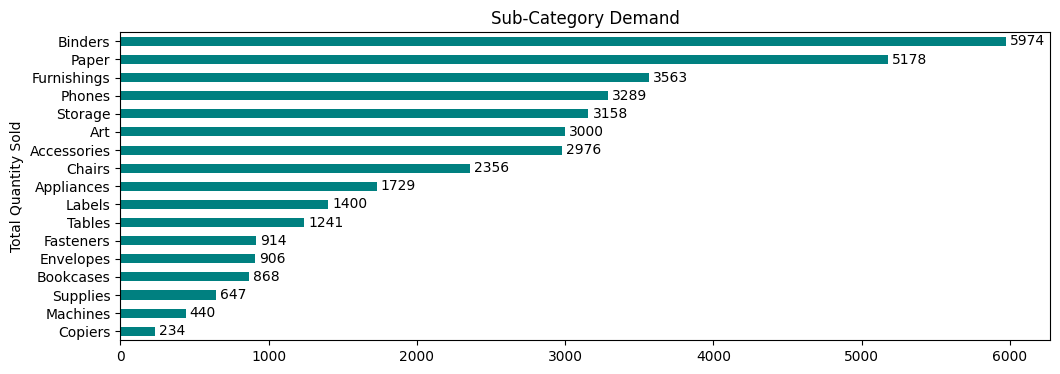

In [126]:
ax = top_products.plot(kind='barh', figsize=(12,4), color='teal', title='Sub-Category Demand')

ax.invert_yaxis()       # Highest value at top

ax.bar_label(ax.containers[0], padding=3)   # Labels to the bars

plt.ylabel("Total Quantity Sold")
plt.show()


In [ ]:
# Save the final cleaned and enriched dataset
df.to_csv("Cleaned_Superstore.csv", index = False)
forecast.to_csv("sales_forecast.csv", index = False)